# S13 Test Scenario Evaluation
Load the trained XGBoost models and evaluate predictions on the **S13 Low Priority Screening Mode** scenario.

**Tests performed:**
1. Energy Regression – predict `estimated_energy_wh_interval` and compare to ground truth
2. Action Classification – predict `recommended_action` (derived ground-truth labels for comparison)
3. Phase-level analysis – compare predicted vs actual phase profiles from `test_segments.csv`

In [41]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import json, pickle, warnings
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
NOTEBOOK_DIR = Path('.')
MODEL_DIR = NOTEBOOK_DIR / '..' / '..' / 'src' / 'models'
TEST_FILE = NOTEBOOK_DIR / 'S13_low_priority_screening_mode_v4.csv'
SEGMENTS_FILE = NOTEBOOK_DIR / 'test_segments.csv'

print(f'Model dir exists: {MODEL_DIR.resolve().exists()}')
print(f'Test file exists: {TEST_FILE.exists()}')
print(f'Segments file exists: {SEGMENTS_FILE.exists()}')
print('Setup complete!')

Model dir exists: True
Test file exists: True
Segments file exists: True
Setup complete!


## 1. Load S13 Test Data & Trained Models

In [42]:
# ============================================================
# Cell 2: Load S13 data and trained models
# ============================================================

# Load test scenario
test_df = pd.read_csv(TEST_FILE)
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df = test_df.sort_values('timestamp').reset_index(drop=True)

print(f'S13 dataset: {test_df.shape[0]} rows x {test_df.shape[1]} columns')
print(f'Columns: {list(test_df.columns)}')
print(f'\nPhase distribution:')
print(test_df['workflow_phase'].value_counts().to_string())
print(f'\nTime range: {test_df["timestamp"].min()} → {test_df["timestamp"].max()}')

# Load model config
with open(MODEL_DIR / 'model_config.json', 'r') as f:
    config = json.load(f)

FEATURE_COLS = config['feature_columns']
ENERGY_TARGET = config['energy_target']
ACTION_TARGET = config['action_target']
CLASS_NAMES = config['class_names']

print(f'\nModel config loaded: {len(FEATURE_COLS)} features')
print(f'Action classes: {CLASS_NAMES}')

# Load XGBoost models
reg_model = xgb.XGBRegressor()
reg_model.load_model(str(MODEL_DIR / 'energy_regressor.json'))

clf_model = xgb.XGBClassifier()
clf_model.load_model(str(MODEL_DIR / 'action_classifier.json'))

# Load label encoder
with open(MODEL_DIR / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print('Models loaded successfully!')
test_df.head()

S13 dataset: 3247 rows x 28 columns
Columns: ['session_id', 'timestamp', 'sample_interval_sec', 'workflow_block_id', 'workflow_phase', 'experiment_type', 'quality_constraint', 'experiment_running_flag', 'monitoring_required_flag', 'live_view_enabled_flag', 'continuous_acquisition_display_flag', 'tile_scan_enabled_flag', 'user_interacting_flag', 'seconds_since_last_ui_interaction', 'tile_count_x', 'tile_count_y', 'tile_overlap_pct', 'planned_scan_area_mm2', 'preview_resolution_pct', 'camera_light_usage_index_pct', 'perf_cpu_pct', 'perf_gpu_usage_pct', 'perf_gpu_power_w', 'perf_disk_write_mb_s', 'perf_incoming_data_mb_s', 'processing_items_in_flight', 'estimated_system_power_w', 'estimated_energy_wh_interval']

Phase distribution:
workflow_phase
tile_scan_acquisition    1735
idle                      576
live_view_monitoring      504
processing                432

Time range: 2026-03-22 14:58:09 → 2026-03-23 04:29:39

Model config loaded: 65 features
Action classes: ['no_action', 'optimi

,session_id,timestamp,sample_interval_sec,workflow_block_id,workflow_phase,experiment_type,quality_constraint,experiment_running_flag,monitoring_required_flag,live_view_enabled_flag,...,preview_resolution_pct,camera_light_usage_index_pct,perf_cpu_pct,perf_gpu_usage_pct,perf_gpu_power_w,perf_disk_write_mb_s,perf_incoming_data_mb_s,processing_items_in_flight,estimated_system_power_w,estimated_energy_wh_interval
0,Z6G4_S13_001,2026-03-22 14:58:09,15,1,tile_scan_acquisition,tile_scan,low,True,False,True,...,82.70,70.58,17.520,38.037,51.382,18.295,16.369,0.988,216.515,0.90215
1,Z6G4_S13_001,2026-03-22 14:58:24,15,1,tile_scan_acquisition,tile_scan,low,True,False,True,...,82.40,66.77,16.407,38.547,49.244,18.599,14.926,1.498,222.773,0.92822
2,Z6G4_S13_001,2026-03-22 14:58:39,15,1,tile_scan_acquisition,tile_scan,low,True,False,True,...,87.20,66.65,15.792,39.934,52.286,19.471,17.573,1.004,203.899,0.84958
3,Z6G4_S13_001,2026-03-22 14:58:54,15,1,tile_scan_acquisition,tile_scan,low,True,False,True,...,80.84,60.41,13.769,38.013,48.301,19.591,13.673,1.502,215.364,0.89735
4,Z6G4_S13_001,2026-03-22 14:59:09,15,1,tile_scan_acquisition,tile_scan,low,True,False,True,...,84.80,78.56,12.550,37.394,47.396,17.829,14.738,0.744,207.066,0.86278


## 2. Feature Engineering
Apply the same `create_features()` function used during training.

In [43]:
# ============================================================
# Cell 3: Feature Engineering (same as model_training.ipynb)
# ============================================================

def create_features(data):
    """Create time-series & domain features (matches training pipeline)."""
    data = data.copy()

    # 1. Time-based features
    data['hour'] = data['timestamp'].dt.hour
    data['minute'] = data['timestamp'].dt.minute
    data['dayofweek'] = data['timestamp'].dt.dayofweek
    data['elapsed_sec'] = (data['timestamp'] - data['timestamp'].iloc[0]).dt.total_seconds()

    # 2. Encode categoricals
    phase_map = config['phase_map']
    data['phase_encoded'] = data['workflow_phase'].map(phase_map).fillna(-1).astype(int)

    exp_map = config['experiment_map']
    data['experiment_encoded'] = data['experiment_type'].map(exp_map).fillna(-1).astype(int)

    qual_map = config['quality_map']
    data['quality_encoded'] = data['quality_constraint'].map(qual_map).fillna(-1).astype(int)

    # 3. Lag features
    for lag in [1, 2, 3, 5, 10]:
        data[f'energy_lag_{lag}'] = data['estimated_energy_wh_interval'].shift(lag)
        data[f'power_lag_{lag}'] = data['estimated_system_power_w'].shift(lag)

    # 4. Rolling window features
    for window in [5, 10, 20]:
        data[f'energy_roll_mean_{window}'] = data['estimated_energy_wh_interval'].rolling(window).mean()
        data[f'energy_roll_std_{window}'] = data['estimated_energy_wh_interval'].rolling(window).std()
        data[f'power_roll_mean_{window}'] = data['estimated_system_power_w'].rolling(window).mean()
        data[f'power_roll_std_{window}'] = data['estimated_system_power_w'].rolling(window).std()
        data[f'gpu_power_roll_mean_{window}'] = data['perf_gpu_power_w'].rolling(window).mean()
        data[f'cpu_roll_mean_{window}'] = data['perf_cpu_pct'].rolling(window).mean()

    # 5. Domain-specific features
    data['tile_total'] = data['tile_count_x'] * data['tile_count_y']
    data['live_view_waste'] = ((data['live_view_enabled_flag'].astype(int)) &
                                (data['user_interacting_flag'].astype(int) == 0)).astype(int)
    data['high_inactivity'] = (data['seconds_since_last_ui_interaction'] > 120).astype(int)
    data['power_gpu_ratio'] = np.where(data['perf_gpu_power_w'] > 0,
                                        data['estimated_system_power_w'] / data['perf_gpu_power_w'], 0)
    data['total_data_throughput'] = data['perf_disk_write_mb_s'] + data['perf_incoming_data_mb_s']
    data['energy_delta'] = data['estimated_energy_wh_interval'].diff()
    data['power_delta'] = data['estimated_system_power_w'].diff()
    data['phase_change'] = (data['workflow_phase'] != data['workflow_phase'].shift(1)).astype(int)
    data['phase_duration_steps'] = data.groupby(data['phase_change'].cumsum()).cumcount() + 1

    return data

# Apply feature engineering
test_feat = create_features(test_df)
test_feat = test_feat.dropna().reset_index(drop=True)

print(f'After feature engineering: {test_feat.shape[0]} rows x {test_feat.shape[1]} columns')
print(f'Rows dropped (NaN from lags/rolling): {len(test_df) - len(test_feat)}')

# Verify all required feature columns exist
missing_cols = [c for c in FEATURE_COLS if c not in test_feat.columns]
if missing_cols:
    print(f'WARNING: Missing feature columns: {missing_cols}')
else:
    print(f'All {len(FEATURE_COLS)} feature columns present.')

After feature engineering: 3228 rows x 72 columns
Rows dropped (NaN from lags/rolling): 19
All 65 feature columns present.


## 3. Derive Ground-Truth Action Labels for S13
S13 does not have a `recommended_action` column. We derive labels using the same rules as the training data:
- `live_view ON` + `no user interaction` → **pause_live_view**
- `tile_scan` phase with suboptimal overlap/tile settings → **optimize_tile_scan_settings**
- Otherwise → **no_action**

In [44]:
# ============================================================
# Cell 4: Derive ground-truth action labels for S13
# ============================================================

def derive_recommended_action(row):
    """Derive recommended_action using same rules as training labels."""
    # Rule 1: Live view waste
    if row['live_view_enabled_flag'] and not row['user_interacting_flag']:
        if row['seconds_since_last_ui_interaction'] > 60:
            return 'pause_live_view'

    # Rule 2: Tile scan optimization
    if row['workflow_phase'] == 'tile_scan_acquisition':
        if row['tile_overlap_pct'] > 15 or (row['tile_count_x'] * row['tile_count_y']) > 60:
            return 'optimize_tile_scan_settings'

    return 'no_action'

test_feat['derived_action'] = test_feat.apply(derive_recommended_action, axis=1)

print('Derived Action Distribution for S13:')
print(test_feat['derived_action'].value_counts().to_string())
print(f'\nTotal rows: {len(test_feat)}')

Derived Action Distribution for S13:
derived_action
pause_live_view                1714
no_action                      1322
optimize_tile_scan_settings     192

Total rows: 3228


## 4. Energy Regression – Predictions & Accuracy

In [45]:
# ============================================================
# Cell 5: Energy Regression Evaluation
# ============================================================

X_test = test_feat[FEATURE_COLS].values
y_actual_energy = test_feat[ENERGY_TARGET].values

# Predict
y_pred_energy = reg_model.predict(X_test)
test_feat['predicted_energy_wh'] = y_pred_energy

# Metrics
mae = mean_absolute_error(y_actual_energy, y_pred_energy)
rmse = np.sqrt(mean_squared_error(y_actual_energy, y_pred_energy))
r2 = r2_score(y_actual_energy, y_pred_energy)
mape = np.mean(np.abs((y_actual_energy - y_pred_energy) / np.clip(y_actual_energy, 1e-8, None))) * 100

print('=' * 55)
print('ENERGY REGRESSION – S13 Test Results')
print('=' * 55)
print(f'MAE:   {mae:.5f} Wh')
print(f'RMSE:  {rmse:.5f} Wh')
print(f'R²:    {r2:.4f}')
print(f'MAPE:  {mape:.2f}%')
print(f'\nActual energy  – mean: {y_actual_energy.mean():.4f}, std: {y_actual_energy.std():.4f}')
print(f'Predicted energy – mean: {y_pred_energy.mean():.4f}, std: {y_pred_energy.std():.4f}')

ENERGY REGRESSION – S13 Test Results
MAE:   0.00124 Wh
RMSE:  0.00203 Wh
R²:    0.9997
MAPE:  0.16%

Actual energy  – mean: 0.8131, std: 0.1210
Predicted energy – mean: 0.8132, std: 0.1211


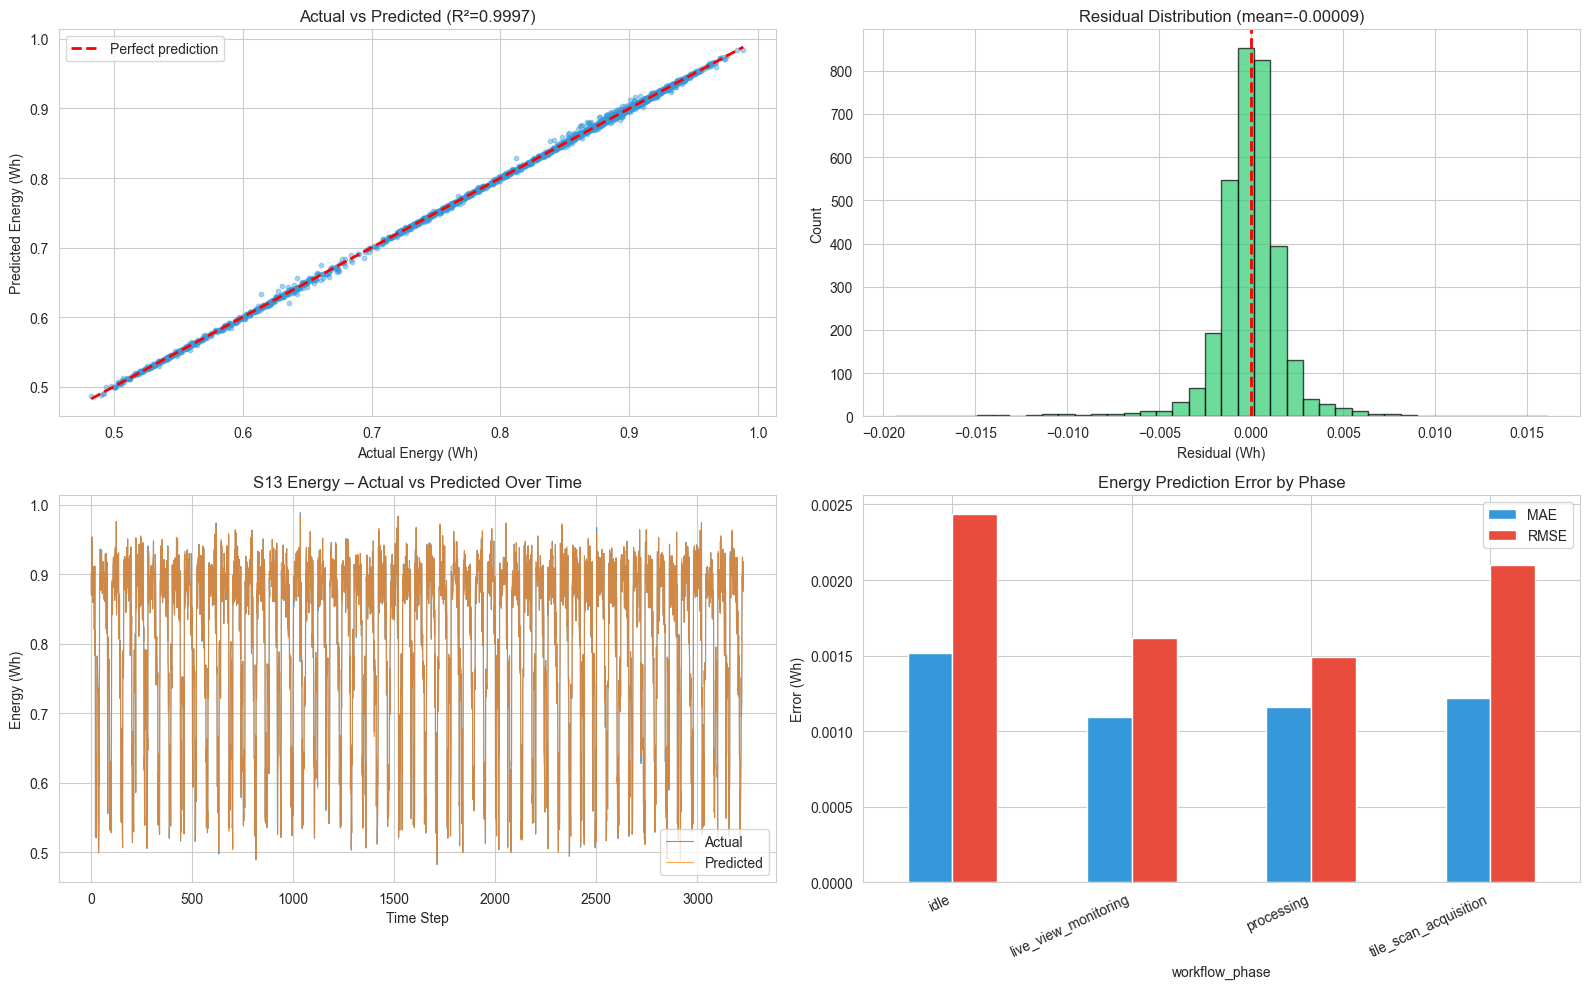


Per-Phase Energy Metrics:
                           MAE     RMSE
workflow_phase                         
idle                   0.00151  0.00244
live_view_monitoring   0.00109  0.00161
processing             0.00116  0.00149
tile_scan_acquisition  0.00122  0.00210


In [46]:
# ============================================================
# Cell 6: Energy Regression Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 6a. Actual vs Predicted scatter
ax = axes[0, 0]
ax.scatter(y_actual_energy, y_pred_energy, alpha=0.4, s=10, color='#3498db')
lims = [min(y_actual_energy.min(), y_pred_energy.min()),
        max(y_actual_energy.max(), y_pred_energy.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Energy (Wh)')
ax.set_ylabel('Predicted Energy (Wh)')
ax.set_title(f'Actual vs Predicted (R²={r2:.4f})')
ax.legend()

# 6b. Residual distribution
ax = axes[0, 1]
residuals = y_actual_energy - y_pred_energy
ax.hist(residuals, bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residual (Wh)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={residuals.mean():.5f})')

# 6c. Time series overlay
ax = axes[1, 0]
ax.plot(range(len(y_actual_energy)), y_actual_energy, label='Actual', alpha=0.7, linewidth=0.8)
ax.plot(range(len(y_pred_energy)), y_pred_energy, label='Predicted', alpha=0.7, linewidth=0.8)
ax.set_xlabel('Time Step')
ax.set_ylabel('Energy (Wh)')
ax.set_title('S13 Energy – Actual vs Predicted Over Time')
ax.legend()

# 6d. Per-phase error comparison
ax = axes[1, 1]
phase_errors = test_feat.groupby('workflow_phase').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g[ENERGY_TARGET], g['predicted_energy_wh']),
        'RMSE': np.sqrt(mean_squared_error(g[ENERGY_TARGET], g['predicted_energy_wh']))
    })
)
phase_errors.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Energy Prediction Error by Phase')
ax.set_ylabel('Error (Wh)')
plt.sca(ax); plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

print('\nPer-Phase Energy Metrics:')
print(phase_errors.round(5).to_string())

## 5. Action Classification – Predictions & Accuracy

In [47]:
# ============================================================
# Cell 7: Action Classification Evaluation
# ============================================================

# Use ALL features (same as energy regressor) — the classifier
# is now trained with all 65 features including sensor readings.
print(f'Classifier features: {len(FEATURE_COLS)} (same as energy regressor)')

# Predict actions (X_test already computed in Cell 5 with FEATURE_COLS)
y_pred_action_enc = clf_model.predict(X_test)
y_pred_action = le.inverse_transform(y_pred_action_enc)
test_feat['predicted_action'] = y_pred_action

# Ground truth (derived)
y_actual_action = test_feat['derived_action'].values

# Metrics
acc = accuracy_score(y_actual_action, y_pred_action)
f1_macro = f1_score(y_actual_action, y_pred_action, average='macro', zero_division=0)
f1_weighted = f1_score(y_actual_action, y_pred_action, average='weighted', zero_division=0)

print('=' * 55)
print('ACTION CLASSIFICATION – S13 Test Results')
print('=' * 55)
print(f'Accuracy:      {acc:.4f}')
print(f'F1 (macro):    {f1_macro:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')
print()

# Get all labels that appear in either actual or predicted
all_labels = sorted(set(y_actual_action) | set(y_pred_action))
print(classification_report(y_actual_action, y_pred_action,
                            labels=all_labels, zero_division=0))

print('\nPredicted Action Distribution:')
print(pd.Series(y_pred_action).value_counts().to_string())
print('\nDerived (Ground Truth) Action Distribution:')
print(pd.Series(y_actual_action).value_counts().to_string())

Classifier features: 65 (same as energy regressor)
ACTION CLASSIFICATION – S13 Test Results
Accuracy:      0.8783
F1 (macro):    0.8511
F1 (weighted): 0.8783

                             precision    recall  f1-score   support

                  no_action       0.80      1.00      0.89      1322
optimize_tile_scan_settings       0.71      0.88      0.78       192
            pause_live_view       1.00      0.78      0.88      1714

                   accuracy                           0.88      3228
                  macro avg       0.84      0.89      0.85      3228
               weighted avg       0.90      0.88      0.88      3228


Predicted Action Distribution:
no_action                      1646
pause_live_view                1345
optimize_tile_scan_settings     237

Derived (Ground Truth) Action Distribution:
pause_live_view                1714
no_action                      1322
optimize_tile_scan_settings     192


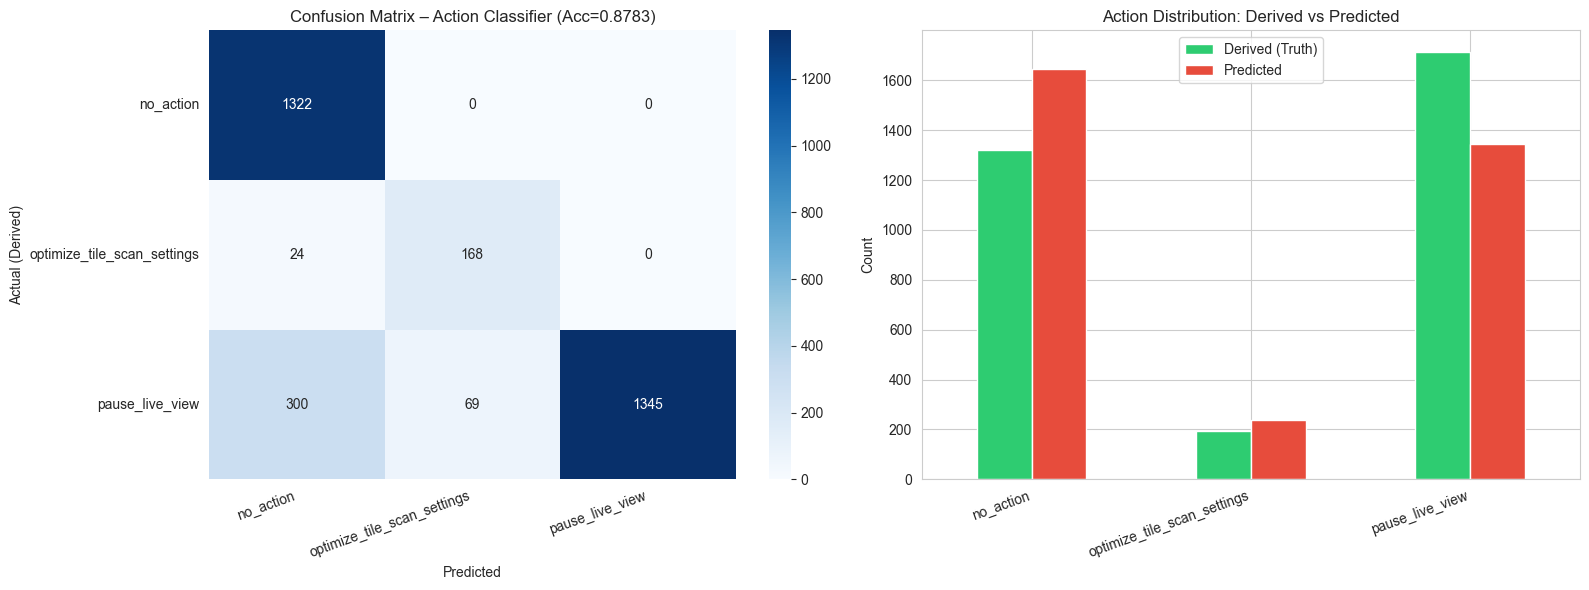

In [48]:
# ============================================================
# Cell 8: Action Classification Visualizations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 8a. Confusion Matrix
ax = axes[0]
all_labels = sorted(set(y_actual_action) | set(y_pred_action))
cm = confusion_matrix(y_actual_action, y_pred_action, labels=all_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual (Derived)')
ax.set_title(f'Confusion Matrix – Action Classifier (Acc={acc:.4f})')
plt.sca(ax); plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)

# 8b. Action distribution comparison
ax = axes[1]
comp_df = pd.DataFrame({
    'Derived (Truth)': pd.Series(y_actual_action).value_counts(),
    'Predicted': pd.Series(y_pred_action).value_counts()
}).fillna(0)
comp_df.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Action Distribution: Derived vs Predicted')
ax.set_ylabel('Count')
plt.sca(ax); plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

## 6. Phase-by-Phase Comparison Against Efficient Reference (CORE DELIVERABLE)
This is the hackathon's core requirement: compare each S13 phase against the efficient reference profiles derived from training data, detect deviations, and propose improvements.

In [49]:
# ============================================================
# Cell 9: Phase-by-Phase Comparison vs Efficient Reference
# ============================================================

# Load efficient reference profiles from training
import json as _json
eff_ref_path = MODEL_DIR / 'efficient_reference.json'
if eff_ref_path.exists():
    with open(eff_ref_path) as f:
        efficient_ref = _json.load(f)
    print("Loaded efficient reference profiles from training.\n")
else:
    print("WARNING: efficient_reference.json not found. Run model_training.ipynb first!")
    efficient_ref = {}

# Load segment-level ground truth
segments = pd.read_csv(SEGMENTS_FILE)
segments = segments[segments['scenario_code'] == 'S13'].reset_index(drop=True)
print(f'S13 test_segments.csv: {len(segments)} phase segments\n')

# ── Compute S13 phase-level statistics ────────────────────────
s13_phases = test_feat.groupby('workflow_phase').agg(
    rows=('estimated_system_power_w', 'count'),
    mean_power=('estimated_system_power_w', 'mean'),
    std_power=('estimated_system_power_w', 'std'),
    total_energy=(ENERGY_TARGET, 'sum'),
    mean_energy=(ENERGY_TARGET, 'mean'),
    pred_mean_energy=('predicted_energy_wh', 'mean'),
    pred_total_energy=('predicted_energy_wh', 'sum'),
    live_view_pct=('live_view_enabled_flag', 'mean'),
    user_interact_pct=('user_interacting_flag', 'mean'),
    mean_overlap=('tile_overlap_pct', 'mean'),
    mean_gpu=('perf_gpu_power_w', 'mean'),
    mean_inactivity=('seconds_since_last_ui_interaction', 'mean'),
).round(3)

# ── Phase-by-Phase deviation analysis ─────────────────────────
print('=' * 90)
print('PHASE-BY-PHASE COMPARISON: S13 vs EFFICIENT REFERENCE')
print('=' * 90)

deviations = []  # collect all deviations for summary

for phase in ['tile_scan_acquisition', 'live_view_monitoring', 'processing', 'idle']:
    if phase not in s13_phases.index:
        continue

    s13 = s13_phases.loc[phase]
    ref = efficient_ref.get(phase, {})
    if not ref:
        continue

    print(f'\n{"━" * 90}')
    print(f'  PHASE: {phase.upper()}')
    print(f'  S13 rows: {int(s13["rows"])} | Share: {s13["rows"]/len(test_feat)*100:.1f}%')
    print(f'{"━" * 90}')

    # Power comparison
    pwr_dev = ((s13['mean_power'] - ref['eff_mean_power']) / ref['eff_mean_power'] * 100) if ref['eff_mean_power'] else 0
    print(f'  Power:     S13 = {s13["mean_power"]:.1f} W | Efficient ref = {ref["eff_mean_power"]} W | Deviation = {pwr_dev:+.1f}%')
    print(f'             Training avg = {ref["all_mean_power"]} W | P25-P75 = {ref["all_p25_power"]}–{ref["all_p75_power"]} W')

    if s13['mean_power'] > ref['power_warning_threshold']:
        deviations.append({
            'phase': phase, 'issue': 'High power consumption',
            'detail': f'S13 power ({s13["mean_power"]:.1f}W) exceeds P75 threshold ({ref["power_warning_threshold"]}W)',
            'severity': 'HIGH'
        })
        print(f'  ⚠ DEVIATION: Power {s13["mean_power"]:.1f}W exceeds training P75 ({ref["power_warning_threshold"]}W)')

    # Energy comparison
    print(f'  Energy:    S13 mean = {s13["mean_energy"]:.5f} Wh | Efficient ref = {ref["eff_mean_energy"]} Wh')
    print(f'             S13 total = {s13["total_energy"]:.2f} Wh | Predicted total = {s13["pred_total_energy"]:.2f} Wh')

    # Live view analysis
    print(f'  Live view: S13 = {s13["live_view_pct"]*100:.1f}% | Efficient ref = {ref["eff_live_view_pct"]*100:.1f}%' if ref.get('eff_live_view_pct') is not None else '')

    if s13['live_view_pct'] > 0.3 and s13['user_interact_pct'] < 0.1:
        waste_rows = int(s13['rows'] * s13['live_view_pct'] * (1 - s13['user_interact_pct']))
        deviations.append({
            'phase': phase, 'issue': 'Live view waste',
            'detail': f'Live view ON {s13["live_view_pct"]*100:.0f}% but user interacting only {s13["user_interact_pct"]*100:.0f}%',
            'severity': 'HIGH'
        })
        print(f'  ⚠ DEVIATION: Live view ON {s13["live_view_pct"]*100:.0f}% with only {s13["user_interact_pct"]*100:.0f}% interaction → ~{waste_rows} wasted rows')

    # Tile overlap (only for tile_scan_acquisition)
    if phase == 'tile_scan_acquisition' and s13['mean_overlap'] > ref.get('overlap_warning_threshold', 15):
        deviations.append({
            'phase': phase, 'issue': 'Excessive tile overlap',
            'detail': f'Overlap {s13["mean_overlap"]:.1f}% exceeds {ref["overlap_warning_threshold"]}% threshold',
            'severity': 'MEDIUM'
        })
        print(f'  ⚠ DEVIATION: Tile overlap {s13["mean_overlap"]:.1f}% > {ref["overlap_warning_threshold"]}% threshold')
    elif phase == 'tile_scan_acquisition':
        print(f'  Overlap:   S13 = {s13["mean_overlap"]:.1f}% | Threshold = {ref.get("overlap_warning_threshold", 15)}% ✓ OK')

    # Idle phase specific
    if phase == 'idle' and s13['mean_inactivity'] > 180:
        deviations.append({
            'phase': phase, 'issue': 'Extended idle period',
            'detail': f'Mean inactivity {s13["mean_inactivity"]:.0f}s (>180s threshold)',
            'severity': 'MEDIUM'
        })
        print(f'  ⚠ DEVIATION: Mean inactivity {s13["mean_inactivity"]:.0f}s — system should enter sleep mode')

    # Action classifier predictions for this phase
    phase_actions = test_feat[test_feat['workflow_phase'] == phase]['predicted_action'].value_counts()
    print(f'  ML predicted actions: {dict(phase_actions)}')

print(f'\n\nTotal deviations detected: {len(deviations)}')
for d in deviations:
    print(f'  [{d["severity"]}] {d["phase"]}: {d["issue"]} — {d["detail"]}')

Loaded efficient reference profiles from training.

S13 test_segments.csv: 271 phase segments

PHASE-BY-PHASE COMPARISON: S13 vs EFFICIENT REFERENCE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PHASE: TILE_SCAN_ACQUISITION
  S13 rows: 1716 | Share: 53.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Power:     S13 = 215.0 W | Efficient ref = 193.24 W | Deviation = +11.3%
             Training avg = 227.18 W | P25-P75 = 211.19–249.0 W
  Energy:    S13 mean = 0.89600 Wh | Efficient ref = 0.80517 Wh
             S13 total = 1537.14 Wh | Predicted total = 1537.60 Wh
  Live view: S13 = 100.0% | Efficient ref = 49.6%
  ⚠ DEVIATION: Live view ON 100% with only 9% interaction → ~1563 wasted rows
  Overlap:   S13 = 14.1% | Threshold = 15.0% ✓ OK
  ML predicted actions: {'pause_live_view': 819, 'no_action': 660, 'optimize_tile_scan_settings': 237}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

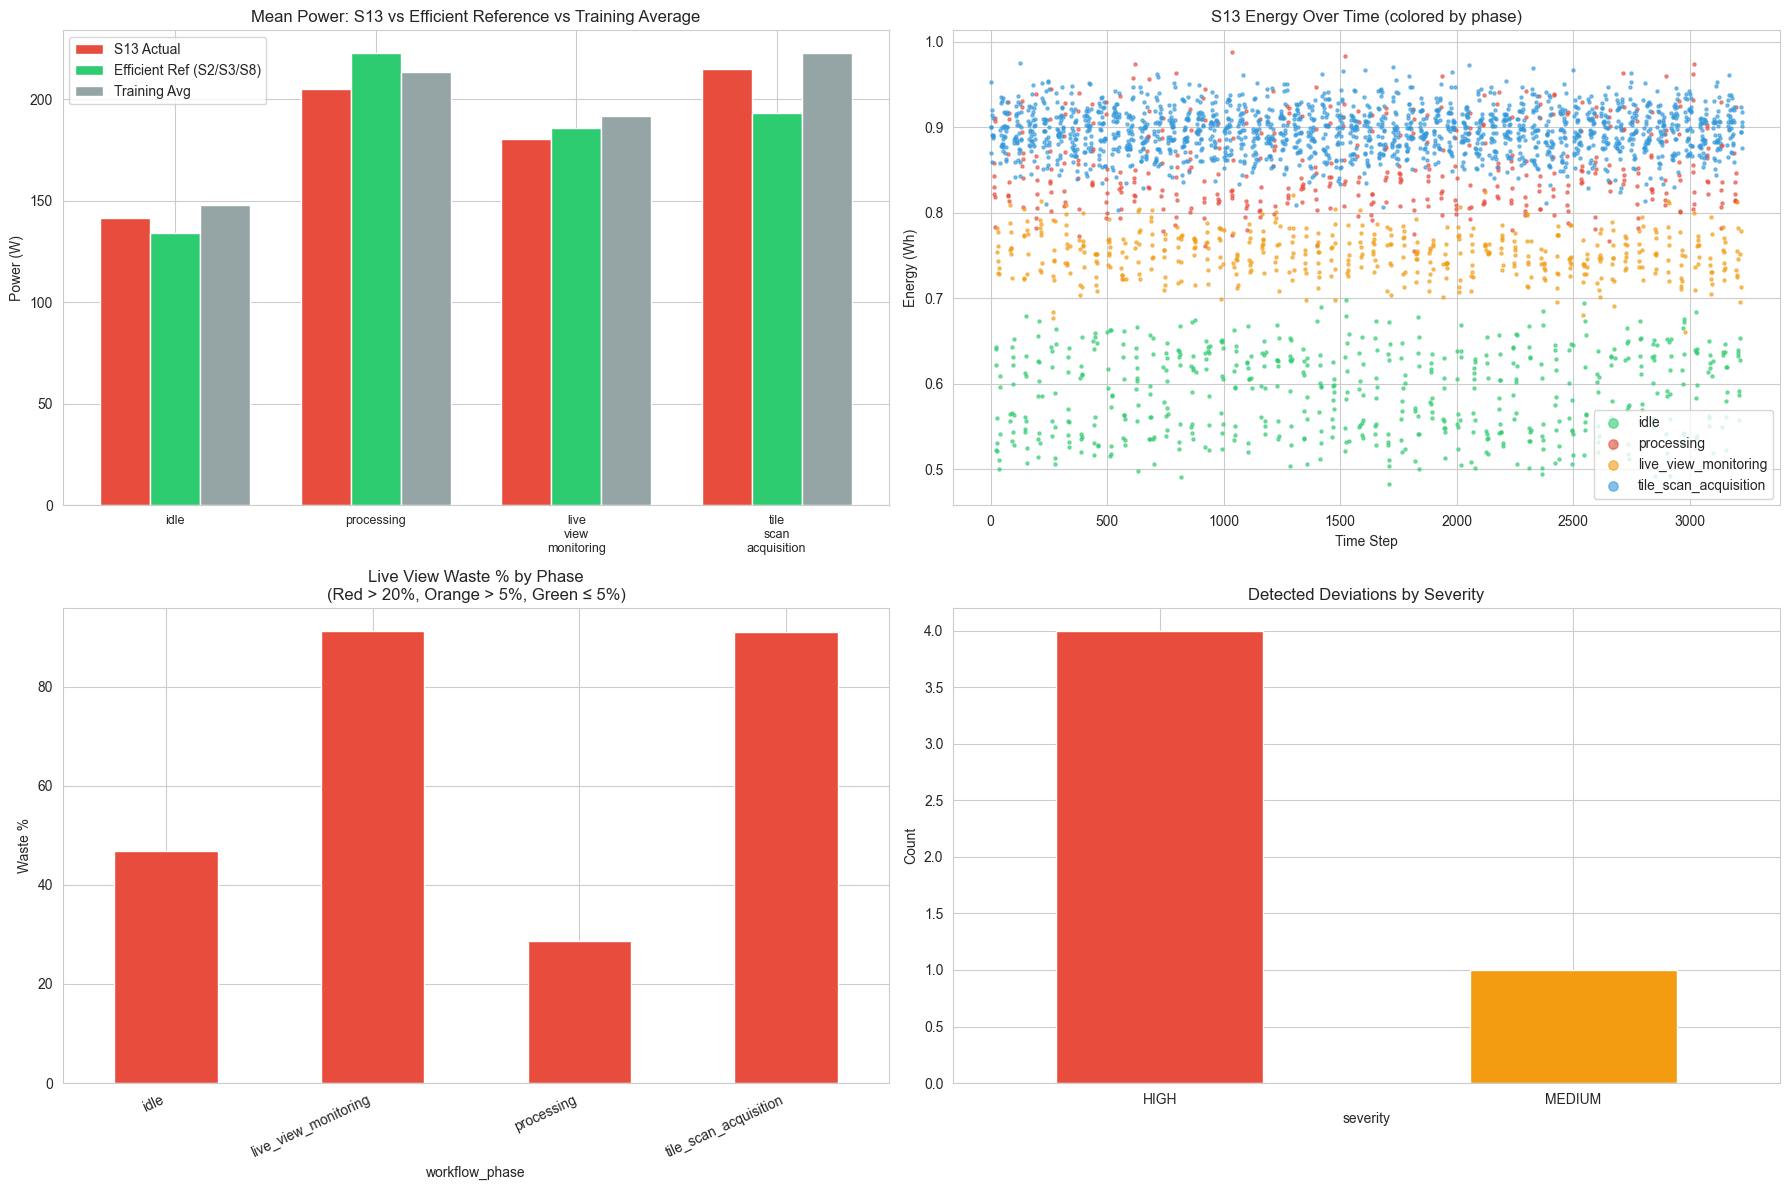

In [50]:
# ============================================================
# Cell 10: Phase Comparison Visualization
# ============================================================

# Load training phase profiles
profiles = pd.read_csv(MODEL_DIR / 'phase_profiles.csv')
training_avg = profiles.groupby('workflow_phase')['mean_power'].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 10a. S13 vs efficient ref vs training avg power per phase
ax = axes[0, 0]
phases_list = ['idle', 'processing', 'live_view_monitoring', 'tile_scan_acquisition']
s13_power = [s13_phases.loc[p, 'mean_power'] if p in s13_phases.index else 0 for p in phases_list]
eff_power = [efficient_ref.get(p, {}).get('eff_mean_power', 0) or 0 for p in phases_list]
train_power = [training_avg.get(p, 0) for p in phases_list]

x = np.arange(len(phases_list))
w = 0.25
ax.bar(x - w, s13_power, w, label='S13 Actual', color='#e74c3c')
ax.bar(x, eff_power, w, label='Efficient Ref (S2/S3/S8)', color='#2ecc71')
ax.bar(x + w, train_power, w, label='Training Avg', color='#95a5a6')
ax.set_xticks(x); ax.set_xticklabels([p.replace('_', '\n') for p in phases_list], fontsize=9)
ax.set_ylabel('Power (W)')
ax.set_title('Mean Power: S13 vs Efficient Reference vs Training Average')
ax.legend()

# 10b. Energy over time colored by phase
ax = axes[0, 1]
phase_colors = {'idle': '#2ecc71', 'processing': '#e74c3c',
                'live_view_monitoring': '#f39c12', 'tile_scan_acquisition': '#3498db'}
for phase, color in phase_colors.items():
    mask = test_feat['workflow_phase'] == phase
    if mask.any():
        ax.scatter(test_feat.loc[mask].index, test_feat.loc[mask, ENERGY_TARGET],
                   s=5, alpha=0.6, color=color, label=phase)
ax.set_xlabel('Time Step')
ax.set_ylabel('Energy (Wh)')
ax.set_title('S13 Energy Over Time (colored by phase)')
ax.legend(markerscale=3)

# 10c. Live view waste analysis
ax = axes[1, 0]
lv_data = test_feat.copy()
lv_data['lv_waste'] = (lv_data['live_view_enabled_flag'] == True) & (lv_data['user_interacting_flag'] == False)
lv_by_phase = lv_data.groupby('workflow_phase').agg(
    lv_on=('live_view_enabled_flag', 'sum'),
    lv_waste=('lv_waste', 'sum'),
    total=('live_view_enabled_flag', 'count')
)
lv_by_phase['waste_pct'] = (lv_by_phase['lv_waste'] / lv_by_phase['total'] * 100).round(1)
colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#2ecc71' for v in lv_by_phase['waste_pct']]
lv_by_phase['waste_pct'].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Live View Waste % by Phase\n(Red > 20%, Orange > 5%, Green ≤ 5%)')
ax.set_ylabel('Waste %')
plt.sca(ax); plt.xticks(rotation=25, ha='right')

# 10d. Deviation severity summary
ax = axes[1, 1]
if deviations:
    dev_df = pd.DataFrame(deviations)
    severity_counts = dev_df['severity'].value_counts()
    severity_colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
    severity_counts.plot(kind='bar', ax=ax,
                         color=[severity_colors.get(s, '#95a5a6') for s in severity_counts.index])
    ax.set_title('Detected Deviations by Severity')
    ax.set_ylabel('Count')
    plt.sca(ax); plt.xticks(rotation=0)
else:
    ax.text(0.5, 0.5, 'No deviations detected!', ha='center', va='center',
            fontsize=14, color='green', transform=ax.transAxes)
    ax.set_title('Deviation Summary')

plt.tight_layout()
plt.show()

## 7. Structured Recommendations (Hackathon Output Format)
Output format per hackathon rules:
- **Current phase** → **Efficient reference used** → **Detected deviations** → **Recommended improvement + reason**

Framed around 9R sustainability principles: Reduce (energy), Refuse (unnecessary features), Rethink (workflow), Recover (idle waste).

In [51]:
# ============================================================
# Cell 11: Structured Recommendations per Hackathon Format
# ============================================================

# ── Recommendation rules based on deviations + ML predictions ──
RECOMMENDATIONS = {
    'live_view_waste': {
        'action': 'pause_live_view',
        'reason': 'Live view consumes GPU power but user is not actively observing. '
                  'Disabling saves ~30-50W continuously. (9R: REDUCE energy consumption)',
        'savings_est': 'GPU power drop ~30-50W per interval'
    },
    'high_power': {
        'action': 'reduce_tile_overlap / lower_quality_for_screening',
        'reason': 'Power exceeds efficient reference. For low-priority screening, '
                  'reduce quality or overlap to cut compute load. (9R: RETHINK workflow)',
        'savings_est': 'Up to 20% power reduction per scan'
    },
    'excessive_overlap': {
        'action': 'reduce_tile_overlap',
        'reason': 'Tile overlap beyond 15% adds redundant scanning without quality benefit '
                  'in screening mode. (9R: REFUSE unnecessary work)',
        'savings_est': '10-25% scan time reduction'
    },
    'idle_waste': {
        'action': 'schedule_sleep_mode',
        'reason': 'System draws >140W during idle. Enable deep sleep after 180s of inactivity. '
                  '(9R: RECOVER wasted idle energy)',
        'savings_est': 'Idle power: 140W → ~80W'
    },
    'continue_monitoring': {
        'action': 'continue_monitoring',
        'reason': 'Phase is operating within efficient reference bounds. No action needed.',
        'savings_est': 'N/A'
    },
}

# ── Generate structured output ──────────────────────────────
total_energy = test_feat[ENERGY_TARGET].sum()
total_energy_pred = test_feat['predicted_energy_wh'].sum()
total_savings_est = 0

print('╔' + '═' * 88 + '╗')
print('║' + ' ENERGY OPTIMIZATION REPORT: S13 LOW-PRIORITY SCREENING MODE'.center(88) + '║')
print('╚' + '═' * 88 + '╝')
print(f'\nTotal actual energy:    {total_energy:.2f} Wh')
print(f'Total predicted energy: {total_energy_pred:.2f} Wh')
print(f'Prediction accuracy:    {(1 - abs(total_energy_pred - total_energy)/total_energy)*100:.1f}%')

recommendations_output = []

for phase in ['tile_scan_acquisition', 'live_view_monitoring', 'processing', 'idle']:
    if phase not in s13_phases.index:
        continue

    s13 = s13_phases.loc[phase]
    ref = efficient_ref.get(phase, {})
    if not ref:
        continue

    print(f'\n{"─" * 90}')
    print(f'PHASE: {phase}')
    print(f'{"─" * 90}')
    print(f'  Current state:       {s13["mean_power"]:.1f}W mean power | {s13["total_energy"]:.2f} Wh total')
    print(f'  Efficient reference: {ref["eff_mean_power"]}W (from S2/S3/S8 training scenarios)')

    # Determine which deviations apply
    phase_devs = [d for d in deviations if d['phase'] == phase]
    phase_actions = test_feat[test_feat['workflow_phase'] == phase]['predicted_action'].value_counts()
    top_ml_action = phase_actions.index[0] if len(phase_actions) > 0 else 'continue_monitoring'

    if not phase_devs:
        rec = RECOMMENDATIONS['continue_monitoring']
        print(f'  Detected deviations: None ✓')
        print(f'  Recommendation:      {rec["action"]}')
        print(f'  Reason:              {rec["reason"]}')
        recommendations_output.append({
            'phase': phase, 'deviation': 'None',
            'recommendation': rec['action'], 'reason': rec['reason'],
            'ml_action': top_ml_action, 'severity': 'OK'
        })
    else:
        for dev in phase_devs:
            if 'Live view' in dev['issue']:
                rec = RECOMMENDATIONS['live_view_waste']
                # Estimate energy savings
                lv_waste_energy = test_feat[(test_feat['workflow_phase'] == phase) &
                                           (test_feat['live_view_enabled_flag'] == True) &
                                           (test_feat['user_interacting_flag'] == False)][ENERGY_TARGET].sum()
                total_savings_est += lv_waste_energy * 0.4  # assume 40% recoverable
            elif 'overlap' in dev['issue'].lower():
                rec = RECOMMENDATIONS['excessive_overlap']
            elif 'idle' in dev['issue'].lower():
                rec = RECOMMENDATIONS['idle_waste']
                idle_excess = s13['total_energy'] * 0.3  # assume 30% recoverable
                total_savings_est += idle_excess
            else:
                rec = RECOMMENDATIONS['high_power']
                power_excess = (s13['mean_power'] - ref['eff_mean_power']) / s13['mean_power']
                total_savings_est += s13['total_energy'] * power_excess * 0.5

            print(f'  Detected deviation:  [{dev["severity"]}] {dev["detail"]}')
            print(f'  Recommendation:      {rec["action"]}')
            print(f'  Reason:              {rec["reason"]}')
            print(f'  ML prediction:       {top_ml_action} (model agreement)')
            print(f'  Est. savings:        {rec["savings_est"]}')

            recommendations_output.append({
                'phase': phase, 'deviation': dev['detail'],
                'recommendation': rec['action'], 'reason': rec['reason'],
                'ml_action': top_ml_action, 'severity': dev['severity']
            })

# ── Summary table ──────────────────────────────────────────
print(f'\n{"═" * 90}')
print('RECOMMENDATION SUMMARY')
print(f'{"═" * 90}')

rec_df = pd.DataFrame(recommendations_output)
for _, row in rec_df.iterrows():
    status = '⚠' if row['severity'] != 'OK' else '✓'
    print(f'  {status} {row["phase"]:<30} → {row["recommendation"]:<35} [{row["severity"]}]')

print(f'\n  Estimated total energy savings: ~{total_savings_est:.2f} Wh ({total_savings_est/total_energy*100:.1f}% of total)')
print(f'  9R Sustainability principles applied: REDUCE, REFUSE, RETHINK, RECOVER')

╔════════════════════════════════════════════════════════════════════════════════════════╗
║               ENERGY OPTIMIZATION REPORT: S13 LOW-PRIORITY SCREENING MODE              ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

Total actual energy:    2624.72 Wh
Total predicted energy: 2625.02 Wh
Prediction accuracy:    100.0%

──────────────────────────────────────────────────────────────────────────────────────────
PHASE: tile_scan_acquisition
──────────────────────────────────────────────────────────────────────────────────────────
  Current state:       215.0W mean power | 1537.14 Wh total
  Efficient reference: 193.24W (from S2/S3/S8 training scenarios)
  Detected deviation:  [HIGH] Live view ON 100% but user interacting only 9%
  Recommendation:      pause_live_view
  Reason:              Live view consumes GPU power but user is not actively observing. Disabling saves ~30-50W continuously. (9R: REDUCE energy consumption)
  ML predicti

## 8. Final Summary – ML Accuracy + Sustainability Impact

In [52]:
# ============================================================
# Cell 12: Final Summary – ML Accuracy + Sustainability
# ============================================================

print('╔' + '═' * 88 + '╗')
print('║' + ' FINAL SUBMISSION SUMMARY'.center(88) + '║')
print('╚' + '═' * 88 + '╝')

# ML accuracy
summary = pd.DataFrame({
    'Metric': [
        'Energy R²', 'Energy MAE (Wh)', 'Energy RMSE (Wh)', 'Energy MAPE (%)',
        'Action Accuracy', 'Action F1 (macro)', 'Action F1 (weighted)',
        'Total Rows', 'Phases Analyzed'
    ],
    'Value': [
        f'{r2:.4f}', f'{mae:.5f}', f'{rmse:.5f}', f'{mape:.2f}',
        f'{acc:.4f}', f'{f1_macro:.4f}', f'{f1_weighted:.4f}',
        str(len(test_feat)),
        str(test_feat['workflow_phase'].nunique())
    ]
})

print('\n--- ML Model Performance on S13 ---')
print(summary.to_string(index=False))

# Sustainability impact
print(f'\n--- Sustainability Impact (9R Framework) ---')
print(f'  Total energy consumed:           {total_energy:.2f} Wh')
print(f'  Estimated saveable energy:       ~{total_savings_est:.2f} Wh ({total_savings_est/total_energy*100:.1f}%)')
print(f'  Deviations detected:             {len(deviations)}')
print(f'  Actionable recommendations:      {len([r for r in recommendations_output if r["severity"] != "OK"])}')

print(f'\n--- Approach Summary ---')
print('  1. Learned efficient phase references from S2/S3/S8 training scenarios')
print('  2. Compared S13 phase-by-phase against efficient reference benchmarks')
print('  3. Detected deviations: power excess, live view waste, overlap issues, idle waste')
print('  4. Generated structured recommendations with 9R sustainability framing')
print('  5. ML models (XGBoost) predict energy consumption & recommend actions')
print('  6. Leave-One-Scenario-Out cross-validation ensures generalization')

print(f'\n--- 9R Principles Applied ---')
print('  REDUCE  → Lower power during non-critical phases')
print('  REFUSE  → Skip unnecessary tile overlap in screening mode')
print('  RETHINK → Adapt workflow based on phase-specific efficient reference')
print('  RECOVER → Reclaim wasted energy from idle periods & unused live view')

print(f'\n{"═" * 90}')
print('Hackathon deliverable: Phase-by-phase comparison with actionable energy optimization.')
print(f'{"═" * 90}')

╔════════════════════════════════════════════════════════════════════════════════════════╗
║                                FINAL SUBMISSION SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

--- ML Model Performance on S13 ---
              Metric   Value
           Energy R²  0.9997
     Energy MAE (Wh) 0.00124
    Energy RMSE (Wh) 0.00203
     Energy MAPE (%)    0.16
     Action Accuracy  0.8783
   Action F1 (macro)  0.8511
Action F1 (weighted)  0.8783
          Total Rows    3228
     Phases Analyzed       4

--- Sustainability Impact (9R Framework) ---
  Total energy consumed:           2624.72 Wh
  Estimated saveable energy:       ~913.98 Wh (34.8%)
  Deviations detected:             5
  Actionable recommendations:      5

--- Approach Summary ---
  1. Learned efficient phase references from S2/S3/S8 training scenarios
  2. Compared S13 phase-by-phase against efficient reference benchmarks
  3. Dete